In [1]:
import os
import keras
import datetime
import numpy as np
import sklearn.metrics
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [2]:
HISTORY_DIR = './history'
os.makedirs(HISTORY_DIR, exist_ok=True)

In [3]:
logdir = os.path.join(HISTORY_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [5]:
rng = np.random.default_rng()

In [6]:
def plot_grid_and_label(dataset: tf.data.Dataset, model: keras.Model | None = None, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)

    if len(dataset.element_spec[0].shape) > 3:
        length = (len(dataset) - 1) * batch_size
        dataset = dataset.unbatch()
    else:
        length = len(dataset)
    
    idx = tf.constant(rng.choice(length, size=np.prod(ax.shape)))

    _, (images, labels) = next(iter(dataset.enumerate().filter(lambda i, j: tf.math.reduce_any(i == idx)).batch(len(idx))))    

    images = images.numpy().reshape(nrows, ncols, *images.shape[1:])
    labels = labels.numpy().reshape(nrows, ncols)

    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])

    if model is not None:
        predictions = np.argmax(model(images.reshape(-1, *images.shape[2:])).numpy(), axis=-1).reshape(nrows, ncols)
        get_title = lambda i, j: f'label: {map_label(labels[i, j])}, prediction: {map_label(predictions[i, j])}'
    else:
        predictions = None
        get_title = lambda i, j: map_label(labels[i, j])
        
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(images[i, j], cmap='gray')
            ax[i, j].set_title(get_title(i, j))
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [7]:
batch_size = 64

In [8]:
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_path = './caltech-101/101_ObjectCategories'

image_size = (128, 128)

label_description = sorted(os.listdir(dataset_path))

In [9]:
train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="int",
    class_names=label_description
)

valid_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="int",
    class_names=label_description
)

Found 9144 files belonging to 102 classes.
Using 7316 files for training.
Found 9144 files belonging to 102 classes.
Using 1828 files for validation.


In [10]:
num_classes = len(label_description)

print(f'Количество классов: {num_classes}')
print('Примеры меток:', label_description[:5])

Количество классов: 102
Примеры меток: ['accordion', 'airplanes', 'anchor', 'ant', 'background_google']


Resize the image to some common size and normalize them to $\left[0,1\right]$.

In [11]:
def resize_and_normalize_image(image: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:    
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [14]:
# def apply_augmentation(image, label):
#     image = augmentations(image, training=True)
#     image = tf.clip_by_value(image, 0.0, 1.0)
#     return image, label

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def augmentations(image, training=False):
    return data_augmentation(image, training=training)


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .map(resize_and_normalize_image, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (augmentations(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

valid_dataset = (
    valid_dataset
    .map(resize_and_normalize_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


In [14]:
total_train = 0
for images, labels in train_dataset:
    total_train += images.shape[0]
print(f"Тренировочных изображений: {total_train}")


Тренировочных изображений: 7316


In [15]:
total_valid = 0
for images, labels in valid_dataset:
    total_valid += images.shape[0]
print(f"Валидационных изображений: {total_valid}")


Валидационных изображений: 1828


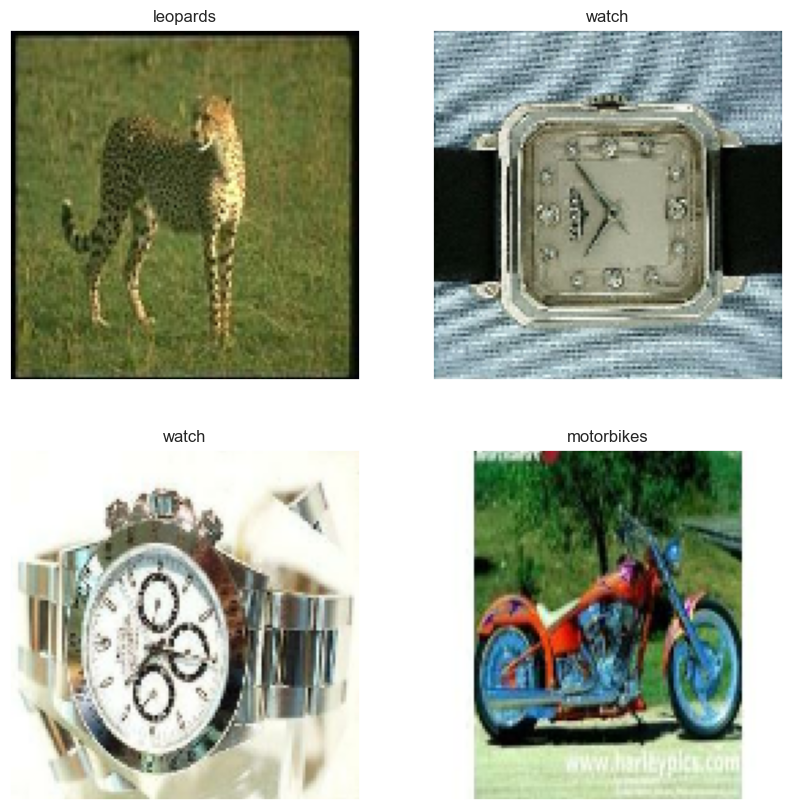

In [16]:
plot_grid_and_label(valid_dataset, label_description=label_description)

# Плоская модель

In [18]:
import tensorflow as tf

img_height, img_width = image_size

# 1 модель - плоская
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_1.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

In [19]:
history_1 = model_1.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 30s 244ms/step - accuracy: 0.1228 - loss: 8.3431 - val_accuracy: 0.1893 - val_loss: 7.1997
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 243ms/step - accuracy: 0.2317 - loss: 6.4553 - val_accuracy: 0.2095 - val_loss: 5.9331
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 243ms/step - accuracy: 0.2560 - loss: 5.5299 - val_accuracy: 0.1636 - val_loss: 5.8107
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.2624 - loss: 5.1131 - val_accuracy: 0.0848 - val_loss: 6.0597
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 242ms/step - accuracy: 0.2614 - loss: 4.9612 - val_accuracy: 0.1193 - val_loss: 6.1138
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 242ms/step - accuracy: 0.2704 - loss: 4.8494 - val_accuracy: 0.0487 - val_loss: 6.6704
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 239ms/step - accuracy: 0.2707 - loss: 4.6883 - val_accuracy: 0.0394 - val_loss: 7.1929
Epoch 8/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 240ms/step - accuracy: 0.2887 -

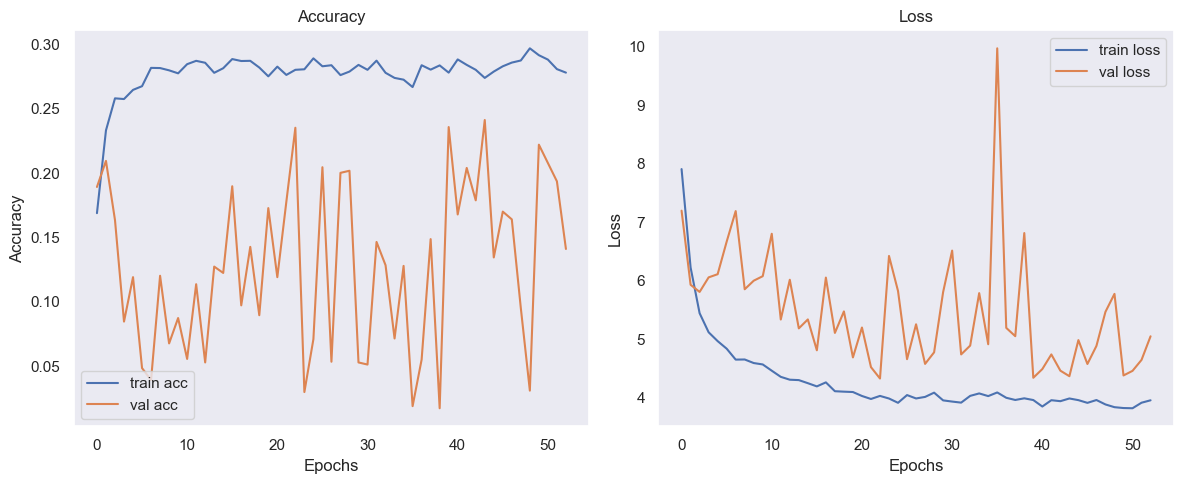

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='train acc')
plt.plot(history_1.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='train loss')
plt.plot(history_1.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
val_loss, val_acc = model_1.evaluate(valid_dataset)
print(f'Validation accuracy: {val_acc:.4f}')
print(f'Validation loss: {val_loss:.4f}')


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2297 - loss: 4.3789
Validation accuracy: 0.2352
Validation loss: 4.3304


In [22]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in valid_dataset:
    preds = model_1.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=label_description))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━

C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\maxim\anaconda3\envs\neural-networks\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

# Двумерная модель

## Model
Prepare your model. Use some convolutional model

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

img_height, img_width = image_size

num_classes = 102

model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint_model = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(logdir, 'model_caltech101.keras'),
    save_best_only=True
)

In [19]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,352,678 (5.16 MB)

 Trainable params: 1,349,798 (5.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

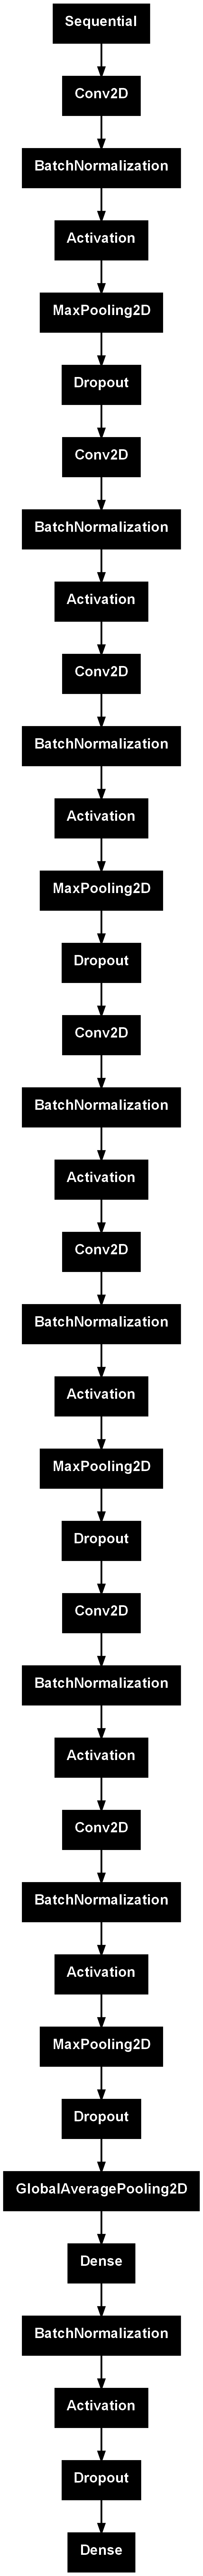

In [20]:
keras.utils.plot_model(model_2)

# Training

Train your model. Use categorical crossentropy loss and top1 and top5 accuracies.

In [18]:
# def to_one_hot(image, label):
#     return image, tf.one_hot(label, depth=num_classes)

# train_dataset_onehot = train_dataset.map(to_one_hot)
# valid_dataset_onehot = valid_dataset.map(to_one_hot)
def one_hot_encode(image: tf.Tensor, label: tf.Tensor):
    return image, tf.one_hot(label, num_classes)

train_dataset_onehot = train_dataset.map(one_hot_encode, num_parallel_calls=AUTOTUNE)
valid_dataset_onehot = valid_dataset.map(one_hot_encode, num_parallel_calls=AUTOTUNE)

In [19]:
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return focal_loss_fixed

In [25]:
# model_2.compile(
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     metrics=[
#         'sparse_categorical_accuracy',
#         keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
#     ]
# )

In [20]:
print("Train size batchs:", len(list(train_dataset_onehot)))
print("Valid size batchs:", len(list(valid_dataset_onehot)))


Train size batchs: 115
Valid size batchs: 29


In [21]:
# Борьба с дисбалансом с помощью весов
from sklearn.utils import class_weight

y_train = []
for _, labels in train_dataset.unbatch():
    y_train.append(labels.numpy())
y_train = np.array(y_train)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

In [22]:
model_2.compile(
    # loss=tf.keras.losses.CategoricalCrossentropy(),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='top_1_accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)

In [23]:
history_2 = model_2.fit(
    train_dataset_onehot,
    validation_data=valid_dataset_onehot,
    epochs=100,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, checkpoint_model]
)

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 102s 841ms/step - loss: 1.4493 - top_1_accuracy: 0.0254 - top_5_accuracy: 0.1116 - val_loss: 1.2668 - val_top_1_accuracy: 0.0383 - val_top_5_accuracy: 0.1767 - learning_rate: 0.0010
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 813ms/step - loss: 1.2846 - top_1_accuracy: 0.0525 - top_5_accuracy: 0.1846 - val_loss: 1.3303 - val_top_1_accuracy: 0.0487 - val_top_5_accuracy: 0.2040 - learning_rate: 0.0010
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 811ms/step - loss: 1.2238 - top_1_accuracy: 0.0811 - top_5_accuracy: 0.2533 - val_loss: 1.2164 - val_top_1_accuracy: 0.0717 - val_top_5_accuracy: 0.2221 - learning_rate: 0.0010
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 813ms/step - loss: 1.1586 - top_1_accuracy: 0.0973 - top_5_accuracy: 0.2870 - val_loss: 1.1629 - val_top_1_accuracy: 0.0749 - val_top_5_accuracy: 0.2478 - learning_rate: 0.0010
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 812ms/step - loss: 1.1055 - top_1_accuracy: 0.1145 - top_5_accurac

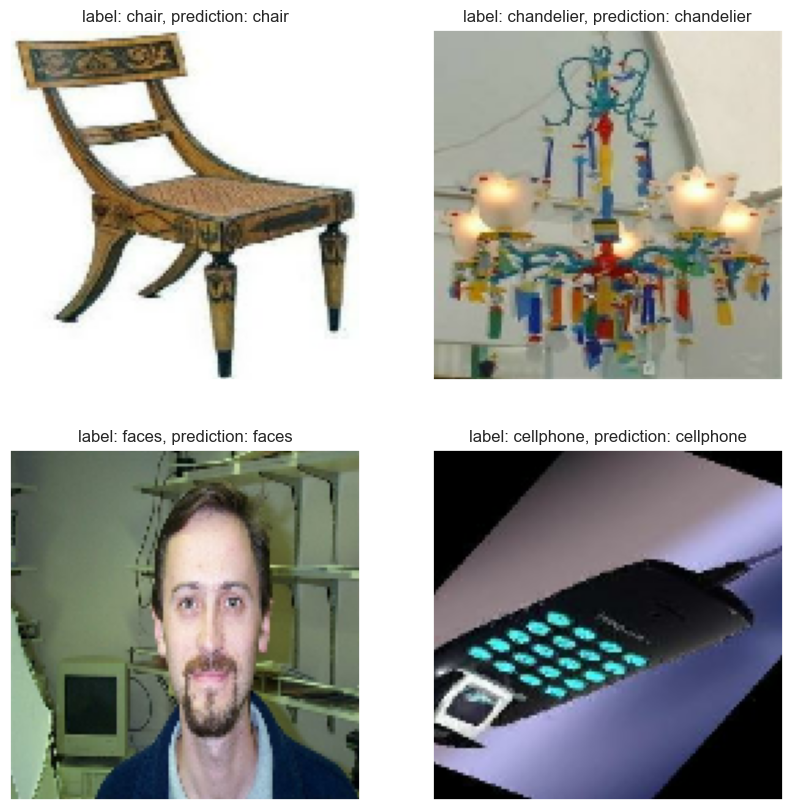

In [24]:
plot_grid_and_label(valid_dataset, model=model_2, label_description=label_description)

# Testing

Plot confusion matrix. Are there similar classes?

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 

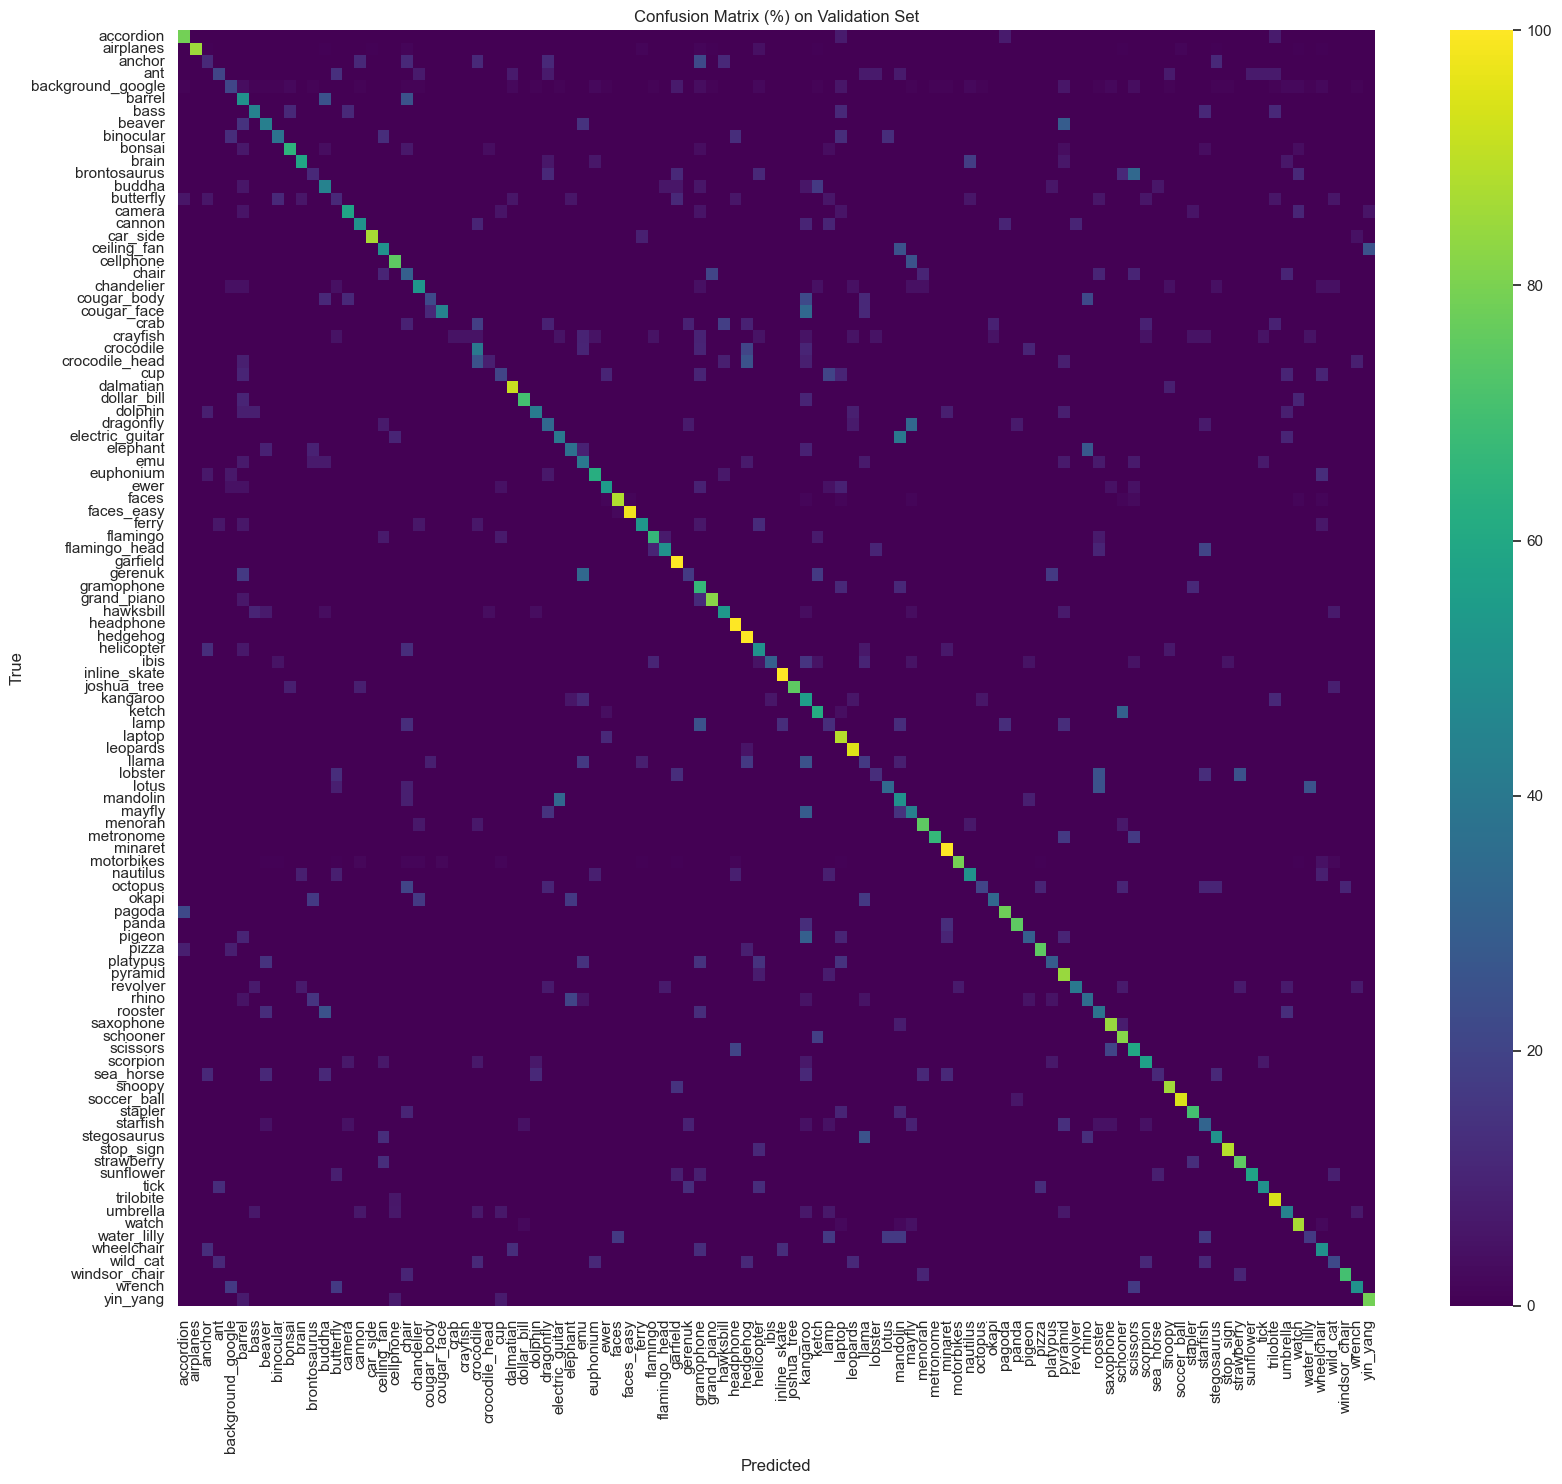

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Получаем истинные и предсказанные метки
y_true = []
y_pred = []

for images, labels in valid_dataset:
    preds = model_2.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Строим confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Приводим к процентам (по строкам)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percent = np.nan_to_num(cm_percent)  # заменяем NaN на 0

# Ограничим матрицу, если классов слишком много
MAX_CLASSES = 102
if len(cm) > MAX_CLASSES:
    print(f"Слишком много классов ({len(cm)}). Показываем только первые {MAX_CLASSES}.")
    cm_percent = cm_percent[:MAX_CLASSES, :MAX_CLASSES]
    short_labels = label_description[:MAX_CLASSES]
else:
    short_labels = label_description

# Визуализируем через seaborn
plt.figure(figsize=(17, 15))
sns.heatmap(cm_percent, annot=False, fmt=".1f", cmap="viridis",
            xticklabels=short_labels, yticklabels=short_labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) on Validation Set")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
from sklearn.metrics import classification_report
import numpy as np

y_true_2 = []
y_pred_2 = []

for images, labels in valid_dataset:
    preds_2 = model_2.predict(images)
    y_true_2.extend(labels.numpy())
    y_pred_2.extend(np.argmax(preds_2, axis=1))

print(classification_report(y_true_2, y_pred_2, target_names=label_description))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 

Get some images from the internet. Do they belong to correct classes according to the model?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


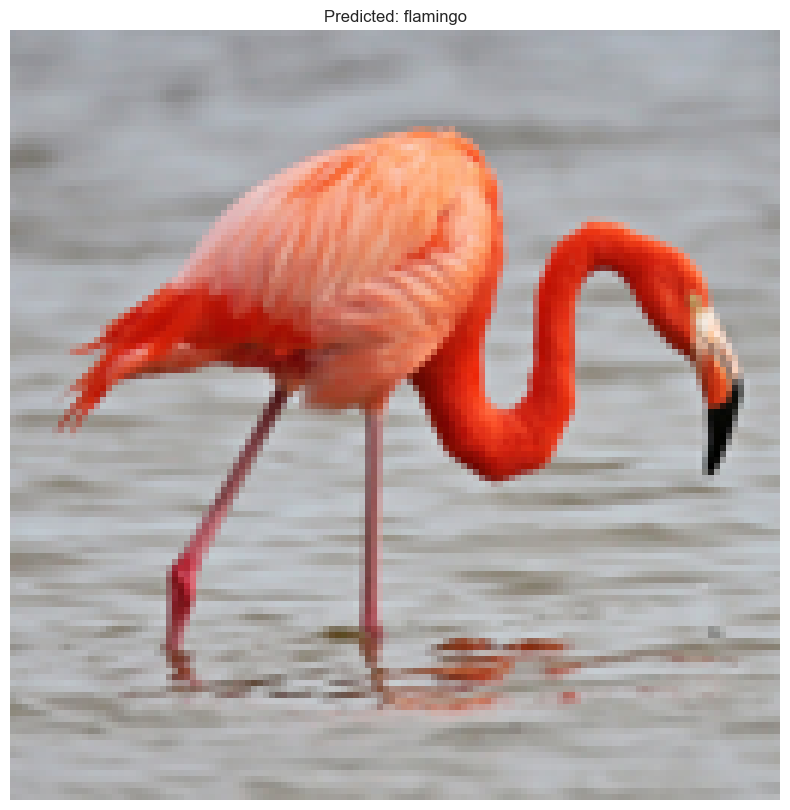

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


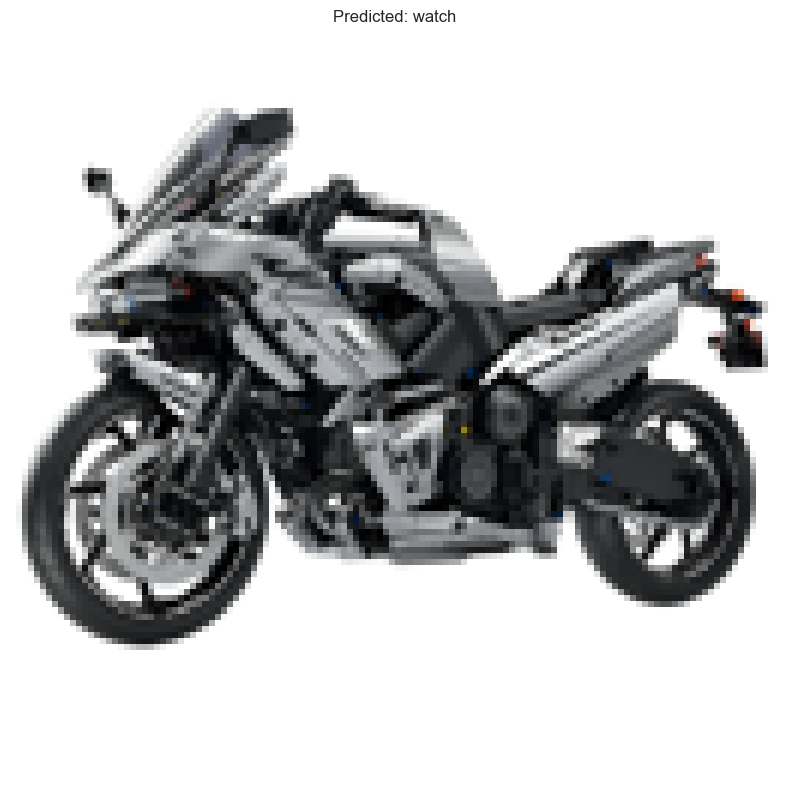

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


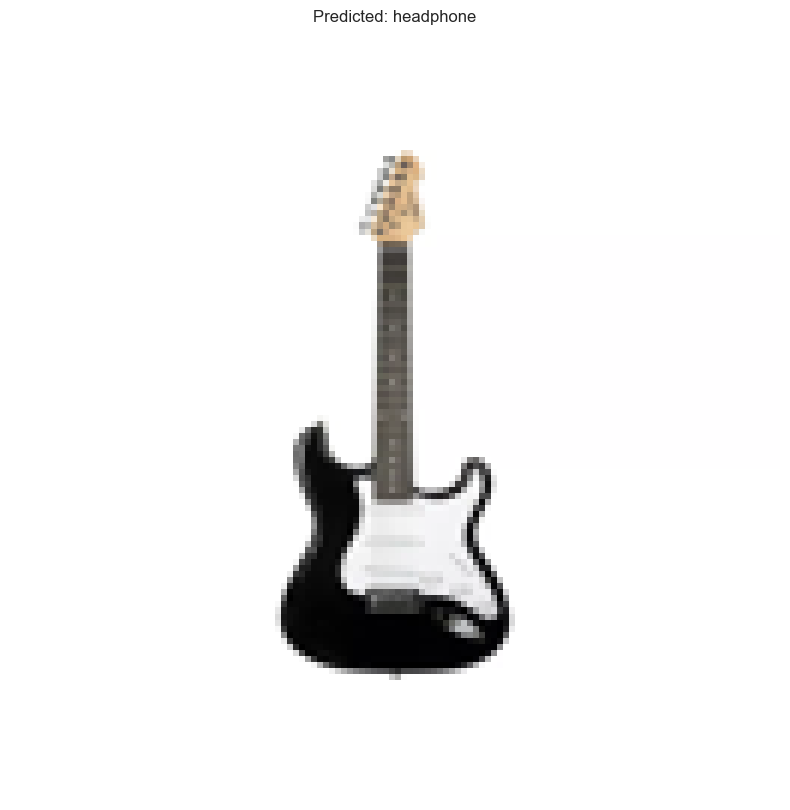

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


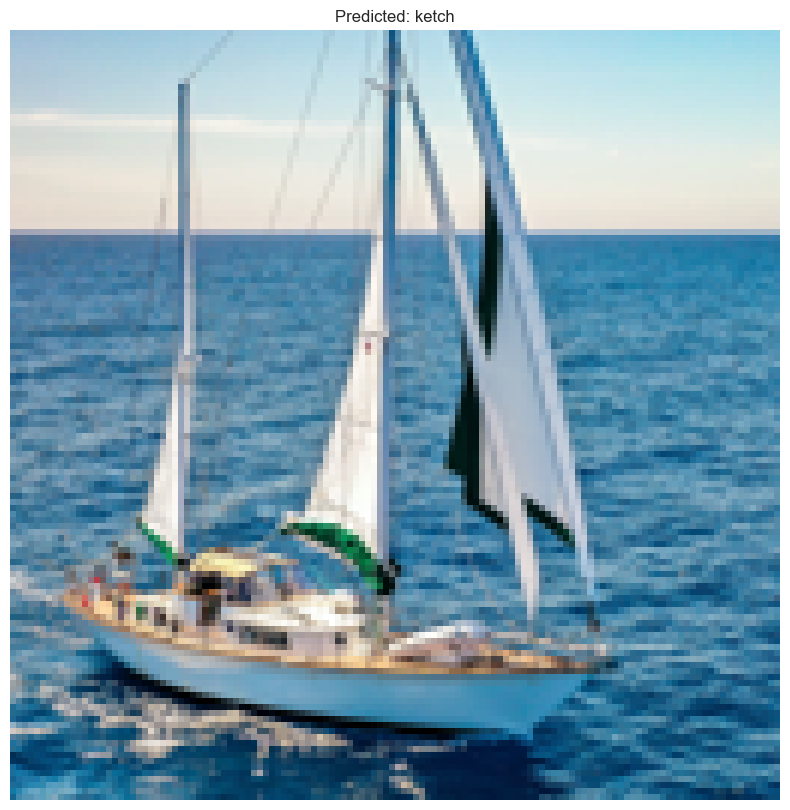

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


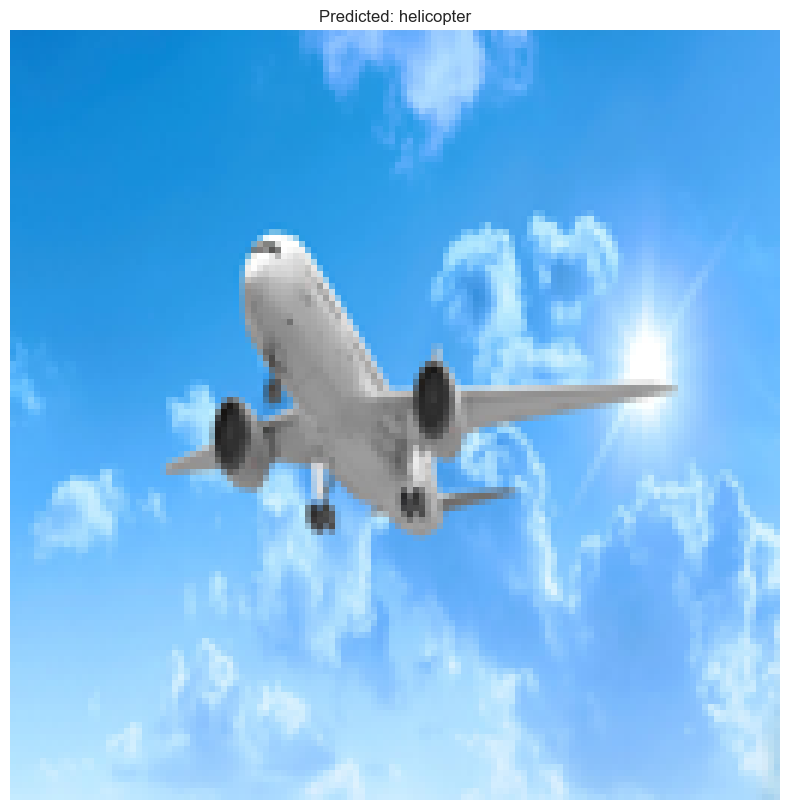

In [27]:
from PIL import Image
import requests
from io import BytesIO

def load_and_prepare_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img = img.resize(image_size)
    img_array = np.array(img) / 255.0
    return img_array

image_urls = [
    "https://cdn.download.ams.birds.cornell.edu/api/v2/asset/320036721/900",
    "https://24builds.com/cdn/shop/files/BC7CA8C9-4745-4661-BD4D-02F638E3CC70.jpg?v=1722422566",
    "https://basket-01.wbbasket.ru/vol119/part11935/11935471/images/big/1.webp",
    "https://portgardneryachts.net/wp-content/uploads/2023/06/Ketch-Sailboat-mason-63-a-true-blue-water-passagemaker-.jpeg",
    "https://images.theconversation.com/files/578175/original/file-20240227-28-cejldv.jpg?ixlib=rb-4.1.0&rect=0%2C0%2C7668%2C3828&q=45&auto=format&w=1356&h=668&fit=crop"
]

for url in image_urls:
    image = load_and_prepare_image(url)
    pred = model_2.predict(np.expand_dims(image, axis=0))
    predicted_label = label_description[np.argmax(pred)]
    
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label}")
    plt.show()


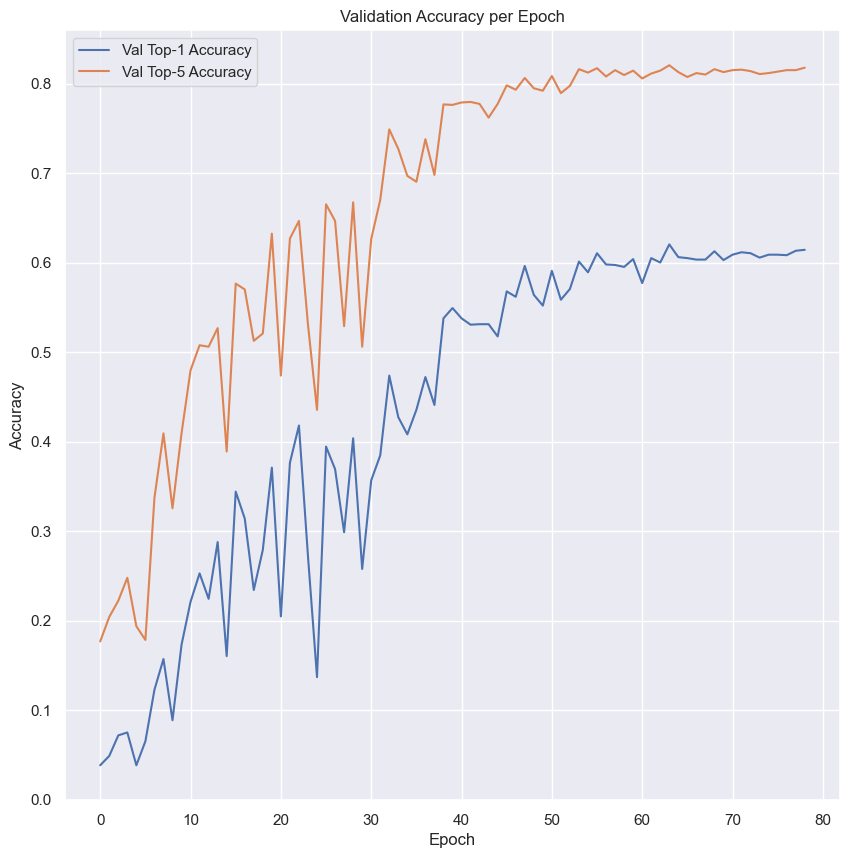

In [28]:
import matplotlib.pyplot as plt

plt.plot(history_2.history['val_top_1_accuracy'], label='Val Top-1 Accuracy')
plt.plot(history_2.history['val_top_5_accuracy'], label='Val Top-5 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
final_val_top1 = history_2.history['val_top_1_accuracy'][-1]
print(f"Validation Top-1 Accuracy: {final_val_top1:.4f}")


Validation Top-1 Accuracy: 0.6143
